# Fall detection using Kinect data
University of Bologna, Computer Vision and Image Processing\
Author: Alfredo Grande\
June 2026

## Goals of this notebook
The aim of this notebook is to explore the feasibility of a fall detection system using only kinect v1 depth data.

The system will be trained and tested on a pre-acquired dataset.
This work serves to provide proof-of-concept with the ultimate goal of building and deploying a real-time fall detection system focused on privacy and reliability for the elderly and vulnerable people.

This project will be divided in 3 main parts:
1. **Introduction on the Kinect v1 sensor:** features, mathematical model, and noise model.
2. **Computer vision pipeline** for feature extraction using depth data
3. **Machine Learning** model building, validation and testing

## Introduction: The Kinect v1 sensor

The Kinect for Xbox 360 (Kinect v1) is a motion-sensing input device released by Microsoft in 2010, designed to let users interact with the console without a physical controller.

The device is comprised of:
- Array of 4 microphones
- Motor to automatically tilt the camera
- RGB camera
- IR camera
- IR projector

<div style="width: auto; max-width: 800px;">

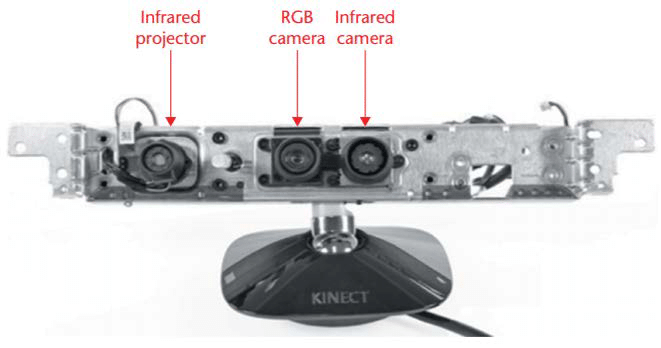

<p style="font-style: italic; font-size: 1em; margin-top: 5px;">
    Kinect sensor
</p>
<p style="font-style: italic; font-size: 0.9em; margin-top: 5px;">
    Autonomous Mobile Robot Visual SLAM Based on Improved CNN Method - Scientific Figure on ResearchGate. Available from: https://www.researchgate.net/figure/Kinect-sensor-infrared-IR-projector-IR-camera-and-RGB-camera-9_fig1_329980203 [accessed 3 Jun 2026]
</p>
</div>

**Main advantages of the Kinect v1**
- Good frame rate.
- Works well indoors, even in low light conditions.
- Low cost and easily accessible.
- The depth images are suitable for privacy preserving applications.

**Limitations of the Kinect v1**
- Infrared light and sunlight can degrade performance.
- Not suitable for outdoor use.
- Limited operative rage.
- Limited accuracy

Below are the main features of the sensors:

<!-- * **Depth sensor type:** Structured light -->
* **RGB camera resolution:** $640 \times 480$, 30 fps, 8bits per channel, Bayer color filter
* **Infrared (IR) camera resolution:** $640 \times 480$, 30fps, 11 bit depth
* **Field of view of RGB image:** $62^\circ \times 48.6^\circ$
* **Field of view of depth image:** $57^\circ \times 43^\circ$
* **Operative measuring range:** 0.8 m–4 m (Default); 0.4 m–3.5 m (Near)
<!-- * **Skeleton joints defined:** 20 joints
* **Maximum skeletal tracking:** 2 -->
> *source: Sarbolandi, Hamed, Damien Lefloch, and Andreas Kolb. "Kinect range sensing: Structured-light versus Time-of-Flight Kinect." Computer vision and image understanding 139 (2015): 1-20.*

### How does the Kinect see depth?

The Kinect is a **Structured Light** sensor: it uses a known pattern of light to detect the depths in the scene via triangulation.

1. The IR projector emits a pseudorandom pattern of speckles in infrared light. This pattern is invisible to the human eye.

2. The image of the pattern, deformed by the objects in the scene, is captured by the IR sensor.

3. The captured frame is compared against a reference image of the same pattern in order to calculate the *horizontal disparity*. This disparity is used to calculate the depth of the pixel via triangulation.

    The speckled pattern simplifies the known issue of *stereo matching* in stereo vision by providing a locally unique pattern even on textureless objects. The matching is probably done by a small horizontally sliding correlation window (9x9 pixels) that compares the local pattern of the captured pixel with sub-sections of the reference image (as speculated on https://wiki.ros.org/kinect_calibration/technical).

> *source: Han, Jungong, et al. "Enhanced computer vision with microsoft kinect sensor: A review." IEEE transactions on cybernetics 43.5 (2013): 1318-1334.*


#### Mathematical Model
<div style="width: auto; max-width: 800px;">

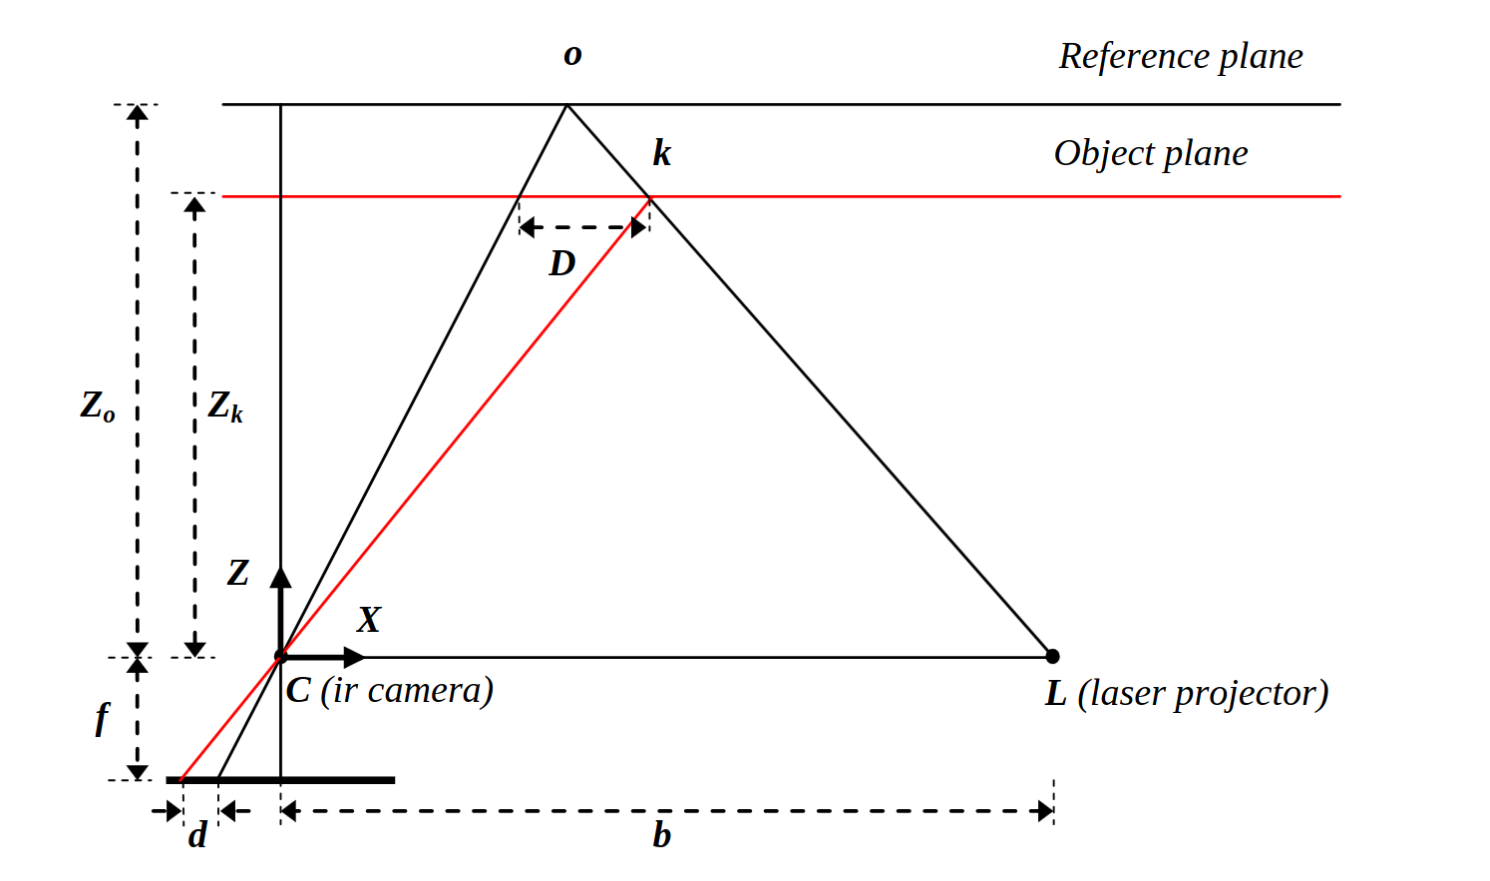

<p style="font-size: 1em; margin-top: 5px;">
    Geometrical model of Kinect
</p>
<p style="font-style: italic; font-size: 0.9em; margin-top: 5px;">
    Khoshelham, Kourosh, and Sander Oude Elberink. "Accuracy and resolution of kinect depth data for indoor mapping applications." sensors 12.2 (2012): 1437-1454.
</p>
</div>

In the figure above we can see the geometrical model of how the kinect computes depth data.
Note that the depths in the Kinect are an estimate of the distance from the camera plane to the object plane, not the actual distance from the object to the sensor.

We consider a reference frame with the origin $O$ at the optical center of the IR camera.

**Offline:**\
The sensor is calibrated by taking a picture of the IR pattern on a reference plane, positioned at a known distance $Z_o$ from the device. This image is saved on the ROM memory of the device. The horizontal distance $b$ (baseline) between the IR camera and the IR projector, is also measured.

**Online:**\
The sensor captures an IR speckle on an object, at an unknown distance $Z_k$ from the optical center.

As a result of the depth difference between the *Reference plane* and the *Object plane*, the speckle undergoes a **horizontal displacement** $D$ in the physical space.

In the image space, this is measured as a pixel **disparity** $d$.

From the similarity of triangles we have:
$$\frac{D}{b} = \frac{Z_o - Z_k}{Z_o}$$

and:

$$\frac{d}{f} = \frac{D}{Z_k}$$

Substituting D in the first equation we get:

$$Z_k \frac{d}{f \cdot b} = \frac{Z_o-Z_k}{Z_o} $$

Solving for $Z_k$:

$$
Z_k = \frac{Z_o}{1+ Z_o \frac{d}{f \cdot b}}
$$

This equation is the core model of depth extraction of the Kinect.

**Point cloud extraction**

$$X_k = -\frac{Z_k}{f} (x_k - x_o + \delta_{x})$$
$$Y_k = -\frac{Z_k}{f} (y_k - y_o + \delta_{y})$$

Where $x_k$ and $y_k$ are the image coordinates of the point, $x_o$ and $y_o$ are the coordinates of the principal
point, and $\delta_ x$ and $\delta_ y$ are corrections for lens distortion.

> *source: Khoshelham, Kourosh, and Sander Oude Elberink. "Accuracy and resolution of kinect depth data for indoor mapping applications." sensors 12.2 (2012): 1437-1454.*

### Normalization

The device does not output the raw disparities $d$ detected by the sensor, instead it normalizes and quantizes them as 11-bit integers between 0 and 2047.

The relation between $d$ and the normalized values $d'$ can be expressed as:

$$d = m \cdot d' + n$$

If we substitute $d$ with $d'$ on the depth equation:

$$Z_k^{-1} = \left(\frac{m}{fb}\right)d' + \left(\frac{1}{Z_o} + \frac{n}{fb}\right)$$

This equation expresses a linear relation between the inverse depth of a point and it corresponding normalized disparity.

When working with the Kinect, we are usually working with inverse of depth $Z_k^{-1}$:
- closer pixels have a higher value
- objects at infinity ($Z_k \to \infty$) have zero disparity and $Z_k^{-1} = 0$.

### Theoretical Random Error Model

If we assume that calibration parameters are perfect and that $d'$ is a random variable with a normal distribution, we can use the law of the propagation of uncertainty to model the error. By propagating the variance of the disparity measure we can obtain the variance of the depth measurement:

$$\sigma_Z^2 = \left( \frac{\partial Z_k}{\partial d'} \right)^2 \sigma_{d'}^2$$

after simplification: 

$$\sigma_Z = \left( \frac{m}{fb} \right) Z_k^2 \sigma_{d'}$$

The error in X and Y is also tied to the depth.

The authors estimated the calibration constant $\left| \frac{m}{fb} \right|$ as $2.85 \times 10^{-5}$ (when depth is measured in centimeters) and assumed a disparity measurement error $\sigma_{d'}$ of $0.5$ pixels.

The intrinsic nature of the disparity quantization method causes two properties:
1. The Depth resolution (minimum measurable depth difference along the Z-axis) is a quadratic function of depth: the spatial resolving power degrades as distance increases.

2. Random error (standard deviation) in depth values is also a quadratic function of depth, that increases at larger distances.

> *source: Khoshelham, Kourosh, and Sander Oude Elberink. "Accuracy and resolution of kinect depth data for indoor mapping applications." sensors 12.2 (2012): 1437-1454.*

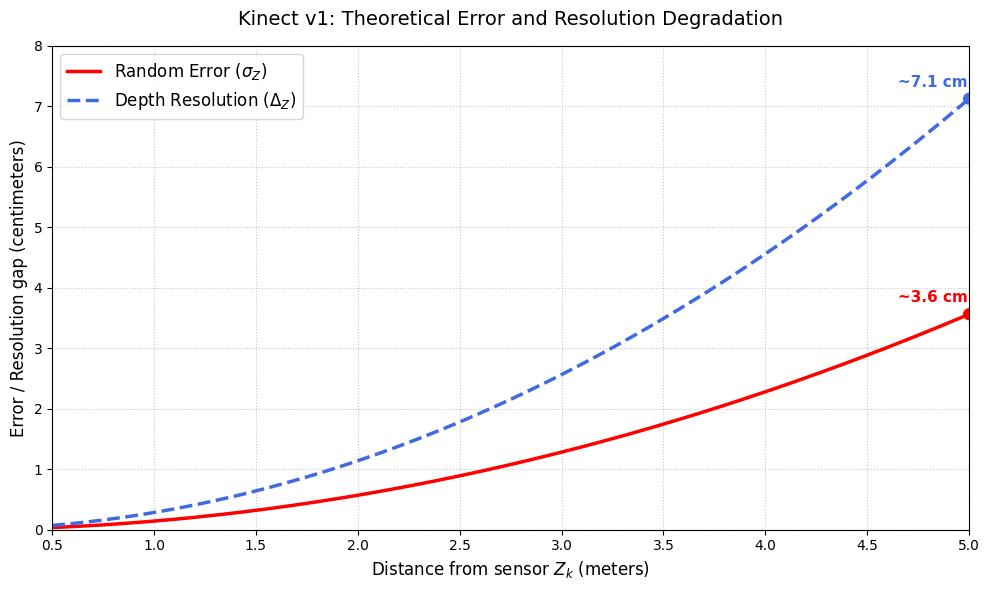

In [1]:
import numpy as np
import matplotlib.pyplot as plt

CALIBRATION_CONSTANT = 2.85e-5  
DISPARITY_MEASUREMENT_ERROR_CONSTANT = 0.5

Z_cm = np.linspace(50, 500, 500)

# Random Error (Standard Deviation)
sigma_z_cm = CALIBRATION_CONSTANT * (Z_cm**2) * DISPARITY_MEASUREMENT_ERROR_CONSTANT

# Depth Resolution (Minimum measurable depth step)
delta_z_cm = CALIBRATION_CONSTANT * (Z_cm**2)

Z_m = Z_cm / 100.0

plt.figure(figsize=(10, 6))

plt.plot(Z_m, sigma_z_cm, label=r'Random Error ($\sigma_Z$)', color='red', linewidth=2.5)
plt.plot(Z_m, delta_z_cm, label=r'Depth Resolution ($\Delta_Z$)', color='royalblue', linestyle='--', linewidth=2.5)

plt.title('Kinect v1: Theoretical Error and Resolution Degradation', fontsize=14, pad=15)
plt.xlabel('Distance from sensor $Z_k$ (meters)', fontsize=12)
plt.ylabel('Error / Resolution gap (centimeters)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.xlim(0.5, 5.0)
plt.ylim(0, 8)

max_error = sigma_z_cm[-1]
max_res = delta_z_cm[-1]

plt.scatter([5.0, 5.0], [max_error, max_res], color=['red', 'royalblue'], zorder=5, s=60)
plt.annotate(f'~{max_error:.1f} cm', (4.65, max_error + 0.2), color='red', weight='bold', fontsize=11)
plt.annotate(f'~{max_res:.1f} cm', (4.65, max_res + 0.2), color='royalblue', weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Fall detection pipeline

### 0. Ingestion

Dataset used: UR Fall detection Dataset: https://fenix.ur.edu.pl/mkepski/ds/uf.html

The Dataset contains 70 sequences (30 falls, 40 ADL).
We will be using only the depth data from the first kinect (cam0), which is positioned parallel to the floor.

Each sequence, acquired at 30fps, is made of 640x480 frames, in PNG16 format. This format needs to be converted back into float with the appropriate scaling:
$$
d = \frac{C_iP(x,y)}{65535}
$$

This dataset is linked to the following paper: https://home.agh.edu.pl/~bkw/research/pdf/2014/KwolekKepski_CMBP2014.pdf
that was used as reference and inspiration for this work.

In [2]:
# flag to display the videos
display_flag = False
display_flag = True

In [3]:
# dataset class
import numpy as np
from pathlib import Path
import cv2

class KinectDataset:
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir).expanduser()
        
        self.sequence_folders = sorted([d for d in self.root_dir.iterdir() if d.is_dir()])

        # falls
        self.falls = [d for d in self.sequence_folders if "fall" in d.name.lower()]
        
        # adl
        self.adl = [d for d in self.sequence_folders if "adl" in d.name.lower()]

    def get_falls(self):
        return self.falls
    
    def get_adl(self):
        return self.adl
        
    def get_fall_sequence(self, idx):
        return self.get_sequence(Path(self.falls[idx]).name)

    def get_adl_sequence(self, idx):
        return self.get_sequence(Path(self.adl[idx]).name)

    def get_sequence(self, idx_or_name):
        """
        Loads a sequence of depth frames from the dataset. 
        The input can be either an index (int) or a folder name (str).

        Args:
            idx_or_name (int or str): Index of the sequence folder or the folder name.
        Returns:
            dict: A dictionary containing:
                - 'name': The name of the sequence.
                - 'data': A tensor of shape (N, H, W) containing the depth frames in millimeters, typed as float32.
                - 'label': 1 if it's a fall sequence, 0 otherwise.
                - 'c_i': The scale parameter used for converting raw depth values to millimeters.
        """
        print(f"Loading sequence: {idx_or_name}")

        if isinstance(idx_or_name, int):
            idx = idx_or_name
            if idx < 0 or idx >= len(self.sequence_folders):
                raise IndexError("Index out of range. Valid range: 0 to {}".format(len(self.sequence_folders) - 1))
            path = self.sequence_folders[idx]
        else:
            path = self.root_dir / idx_or_name
        name = path.name
        
        is_fall = 1 if "fall" in name.lower() else 0
        
        # Parametro di scala C_i
        if is_fall:
            c_i = 6000.0 if "cam0" in name.lower() else 3640.0
        else:
            c_i = 7000.0
            
        # Importazione frame
        frame_paths = sorted(path.glob("*.png"))
        frames = []
        for p in frame_paths:
            img = cv2.imread(str(p), cv2.IMREAD_ANYDEPTH)
            if img is not None:
                # Scaling in millimetri
                frames.append(((img / 65535.0) * c_i).astype(np.float32))
        
        return {
            "name": name,
            "data": np.stack(frames, axis=0), # Tensor (N, H, W)
            "label": is_fall,
            "c_i": c_i
        }

    def __len__(self):
        return len(self.sequence_folders)

In [4]:
# display functions
import numpy as np
import cv2
from IPython.display import clear_output, display, Image
import time
import itertools

def render_frame(frame, colormap=None, mask=None, bbox=None, plane_eq=None, intrinsics=None):
    """
    Helper function for rendering pipeline. 
    Handles normalization, color space conversions, geometric overlays, and physical occlusion.
    """
    # 1. Normalization
    if frame.max() <= 1:
        norm_frame = (frame * 255).astype(np.uint8)
    else:
        norm_frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    # 2. Base Color Allocation
    if colormap is not None:
        base_color = cv2.applyColorMap(norm_frame, colormap)
    else:
        base_color = cv2.cvtColor(norm_frame, cv2.COLOR_GRAY2BGR)
        
    canvas = base_color.copy()
        
    # 3. Floor Grid Rendering (Z-Index: Background)
    if plane_eq is not None and intrinsics is not None:
        A, B, C, D = plane_eq
        fx, fy, cx, cy = intrinsics
        
        if abs(B) > 1e-6:
            def project_point(X, Z):
                Y = (-A * X - C * Z - D) / B
                u = int((X * fx) / Z + cx)
                v = int((Y * fy) / Z + cy)
                return (u, v)

            grid_color = (255, 0, 0)  # Blue channel
            thickness = 1
            z_range, x_range, step_mm = (500, 5000), (-2000, 2000), 500

            # Draw longitudinal and transversal lines
            for X in range(x_range[0], x_range[1] + step_mm, step_mm):
                prev_pt = None
                for Z in range(z_range[0], z_range[1] + step_mm, step_mm):
                    pt = project_point(X, Z)
                    if prev_pt is not None:
                        cv2.line(canvas, prev_pt, pt, grid_color, thickness)
                    prev_pt = pt

            for Z in range(z_range[0], z_range[1] + step_mm, step_mm):
                prev_pt = None
                for X in range(x_range[0], x_range[1] + step_mm, step_mm):
                    pt = project_point(X, Z)
                    if prev_pt is not None:
                        cv2.line(canvas, prev_pt, pt, grid_color, thickness)
                    prev_pt = pt

    # 4. Mask Overlay & Occlusion (Z-Index: Foreground)
    if mask is not None:
        # Erase the grid underneath the subject by restoring the original depth pixels
        canvas[mask > 0] = base_color[mask > 0]
        
        # Apply the red alpha blending on the clean pixels
        mask_layer = np.zeros_like(canvas)
        mask_layer[mask > 0] = [0, 0, 255]  # Red channel
        canvas = cv2.addWeighted(canvas, 0.6, mask_layer, 0.4, 0)
        
    # 5. Bounding Box Rendering (Z-Index: UI Overlay)
    if bbox is not None:
        x, y, w, h = bbox
        cv2.rectangle(canvas, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green channel
        
    return canvas

def display_sequence(frames, compare_frames=None, masks=None, bboxes=None, 
                     colormap=None, compare_colormap=None, labels=None, 
                     fps=30, plane_eq=None, intrinsics=None):
    """
    Function to display a sequence of frames with optional comparison, masks, bounding boxes, and floor grid.
    """
    if not display_flag:
        return

    delay = 1.0 / fps
    
    seq_compare = compare_frames if compare_frames is not None else itertools.repeat(None)
    seq_masks = masks if masks is not None else itertools.repeat(None)
    seq_bboxes = bboxes if bboxes is not None else itertools.repeat(None)
    
    for f1, f2, m, b in zip(frames, seq_compare, seq_masks, seq_bboxes):
        
        # Rendering stream primario
        vis_main = render_frame(f1, colormap, m, b, plane_eq, intrinsics)
        if labels and labels[0]:
            cv2.putText(vis_main, labels[0], (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
            
        final_canvas = vis_main
        
        # Rendering stream secondario
        if f2 is not None:
            vis_sec = render_frame(f2, compare_colormap, None, None, plane_eq, intrinsics)
            if labels and len(labels) > 1 and labels[1]:
                cv2.putText(vis_sec, labels[1], (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
            final_canvas = np.hstack((vis_main, vis_sec))
            
        # Encoding e I/O
        ret, encoded_image = cv2.imencode('.png', final_canvas)
        if ret:
            clear_output(wait=True)
            display(Image(data=encoded_image.tobytes()))
            time.sleep(delay)

In [5]:
ds = KinectDataset("dataset")
print(f"Falls found: {len(ds.get_falls())}")
print(f"ADL (Activities of Daily Living) found: {len(ds.get_adl())}")


sample = ds.get_sequence(0)
print(f"Sequence: {sample['name']}")
print(f"Label: {sample['label']} - {'Fall' if sample['label'] == 1 else 'No Fall'}")
print(f"Shape: {sample['data'].shape}")
print(f"Data type: {sample['data'].dtype}")

fall = ds.get_fall_sequence(0)
adl = ds.get_adl_sequence(0)

print(f"First Fall Sequence: {fall['name']} - Label: {fall['label']}")
print(f"First ADL Sequence: {adl['name']} - Label: {adl['label']}")

#remove
del sample
del fall
del adl

Falls found: 30
ADL (Activities of Daily Living) found: 40
Loading sequence: 0
Sequence: adl-01-cam0-d
Label: 0 - No Fall
Shape: (150, 480, 640)
Data type: float32
Loading sequence: fall-01-cam0-d
Loading sequence: adl-01-cam0-d
First Fall Sequence: fall-01-cam0-d - Label: 1
First ADL Sequence: adl-01-cam0-d - Label: 0


### Display the first video sequence

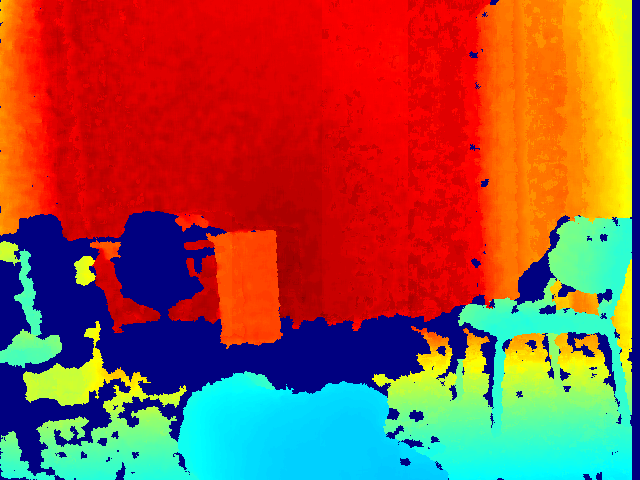

In [6]:
# sample = ds.get_adl_sequence(25)
# sample = ds.get_adl_sequence(22)
sample = ds.get_fall_sequence(4)
frames = sample['data']

display_sequence(frames, colormap=cv2.COLORMAP_JET)

### 1. Filtering
We can see that the depth data from the kinect is very noisy.
We have different kinds of noise and artifacts: 

+ **Holes:** 

    Across the whole image there are various holes, where we don't have any depth (pixel value is 0).
    We can observe in the image small empty regions that are caused by random sensor noise and larger void areas: those areas are usually caused by reflective materials or angled surfaces, which deflect the IR pattern and do not allow the sensor to detect any depth value.

    We can also see that some of the bigger holes are located around objects: these are called *Shadows*.

+ **Shadows**: 
    
    This kind of artifact happens because of the horizontal displacement between the IR camera and IR projector: objects occlude parts of the structured light emitted and the sensor is not able to detect any depth in these areas. 
    
    This noise is not really a problem for our purpose, since it doesn't alter the subject and separates it from the background.

+ **Flickering:** 

    We can observe flickering and fluctuations of the values between consecutive frames. This is due to noise and sensor error.

<div style="width: 600px;">

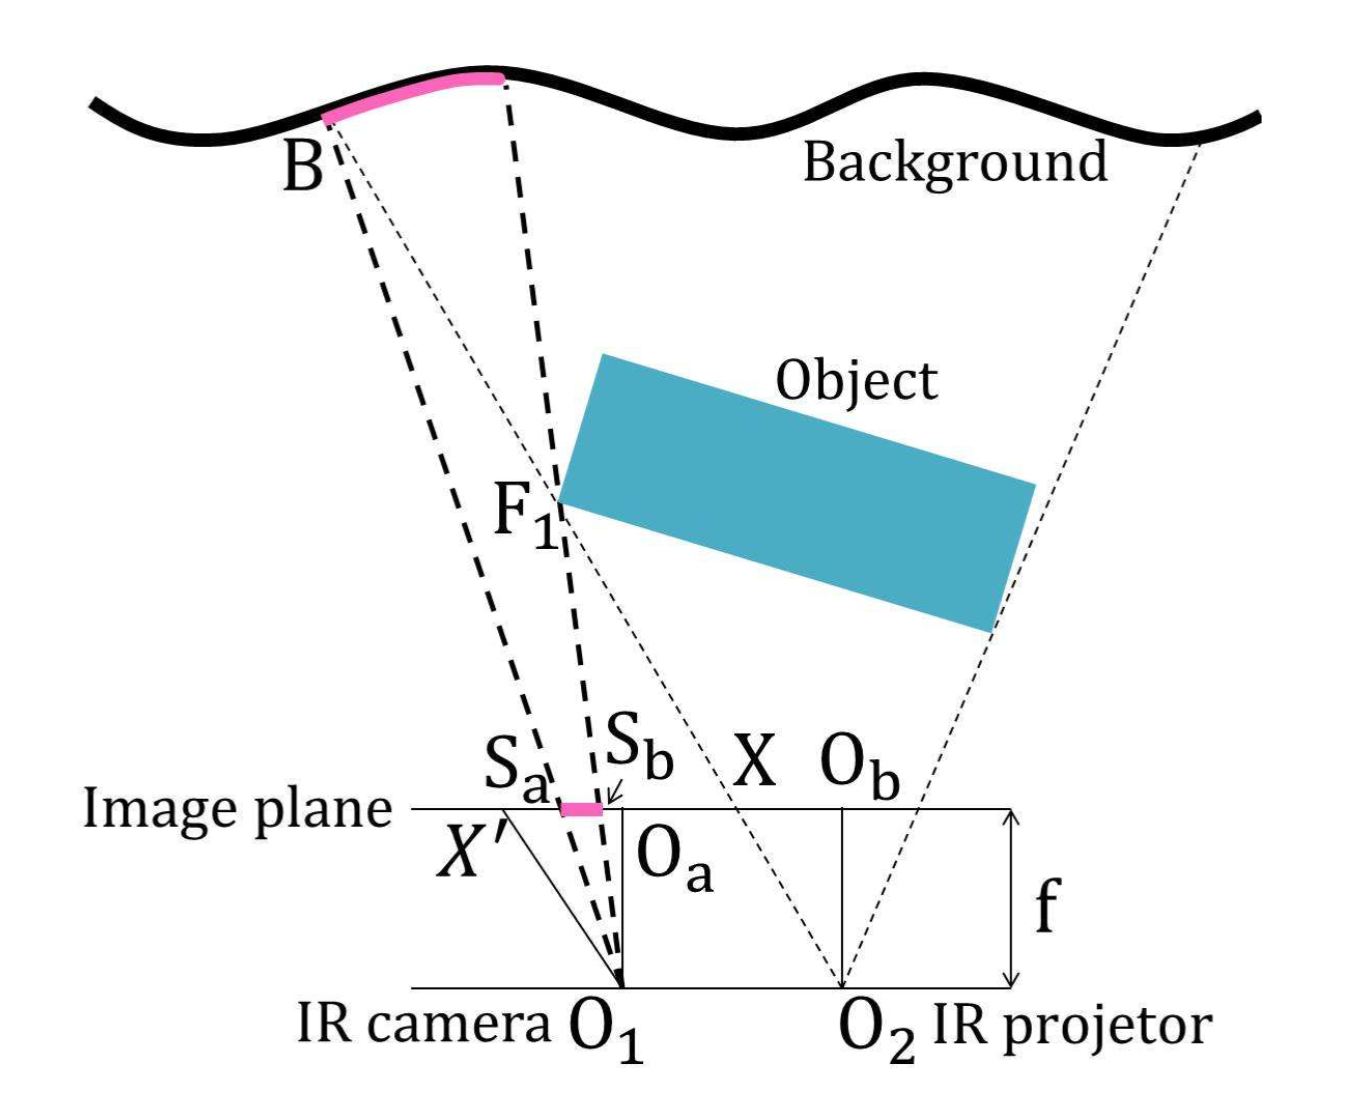

<p style="font-size: 1em; margin-top: 5px;">
    Formation of the Shadow artifact
<p style="font-style: italic; font-size: 0.9em; margin-top: 5px;">
    Kinect Shadow Detection and Classification - Scientific Figure on ResearchGate. Available from: https://www.researchgate.net/figure/maging-geometry-of-Kinect-illustrating-different-types-of-shadows_fig3_262206531
</p>
</p>

<!-- 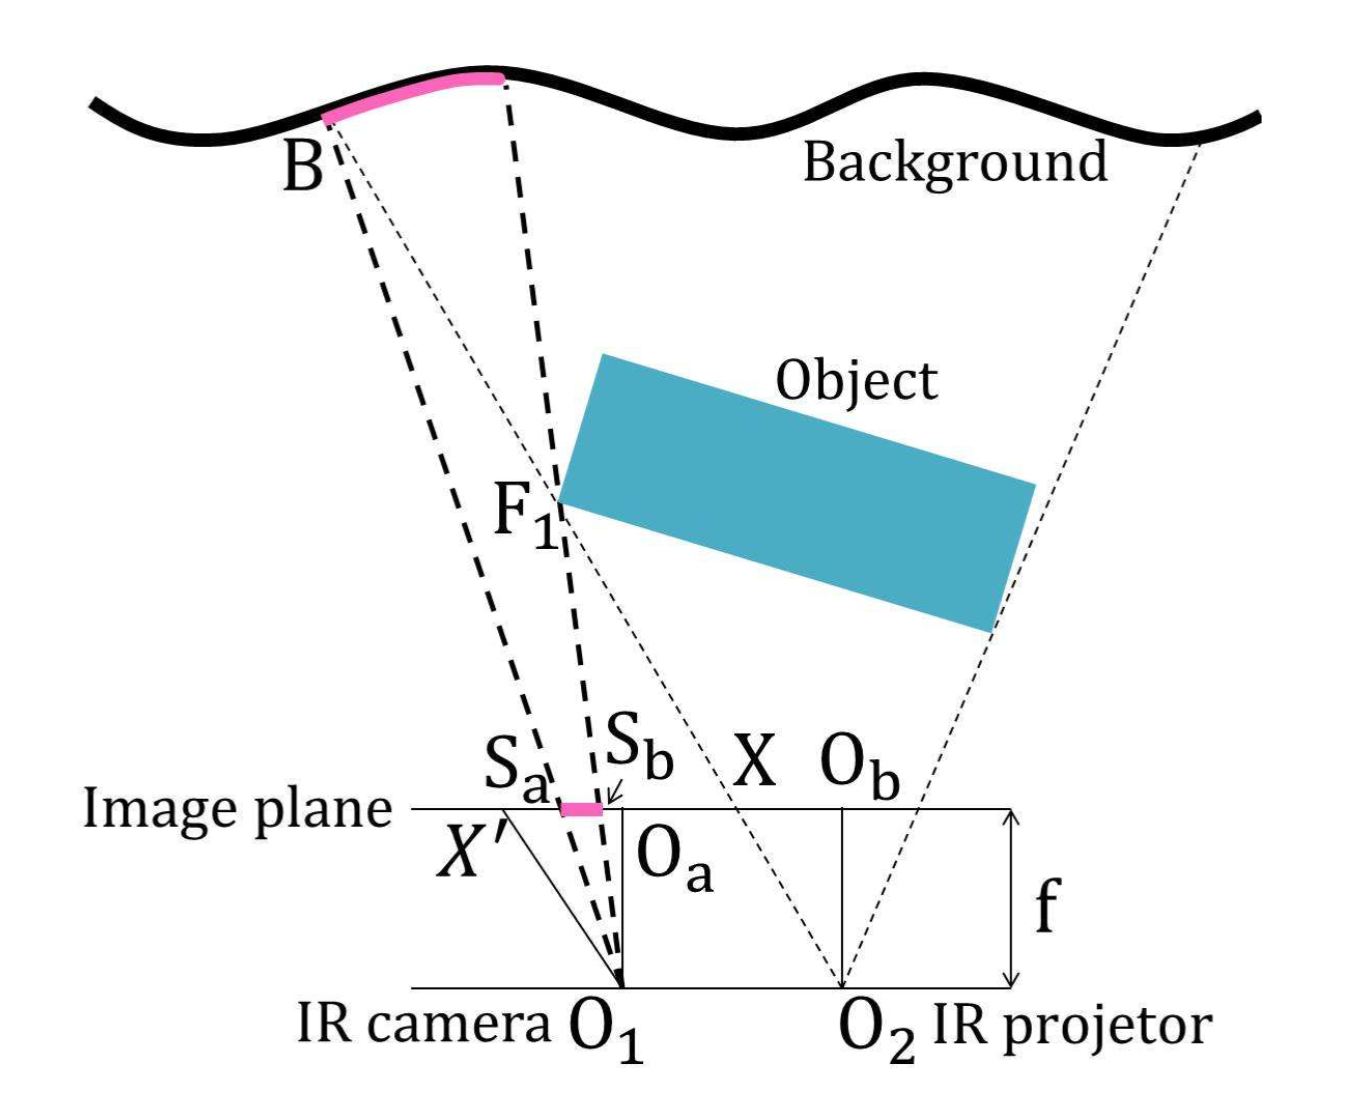 -->

#### Temporal median filter
To reduce flickering across the sequence, we can apply a filter along the temporal axis. 

The median filter with a window size of 3 frames was chosen.

For a pixel $p_n$ taken in frame $n$ we look at $p_{n-1}$ and $p_{n+1}$ and sort them by intensity.
To calculate the final value of $p_{n}$ we take the middle pixel of the sorted sequence.

We must pay attention to not propagate sensor error: the filter should not set to zero a pixel that had valid depth data.

Advantages:
- smooth surfaces appear more stable across time
- flickering is reduced
- unlike the average, this technique does not introduce synthetic values

Disadvantages:
- if the window size is too big, it can cause serious ghosting artifacts in moving subjects.


In [7]:
import numpy as np
from scipy.ndimage import median_filter

def apply_temporal_median_filter(sequence_tensor, window_size=3):
    """
    Applies a 1D median filter vectorized along the temporal axis.
    """
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd.")
        
    filtered = median_filter(
        sequence_tensor, 
        size=(window_size, 1, 1), 
        mode='reflect'
    )
    
    # The median filter can introduce zeros in places where there were valid depth values, especially if there are consecutive frames with missing data (zeros).
    # To mitigate this, we restore original values where the filter has set them to zero but the original data had valid depth values.
    
    restored_tensor = np.where(
        (filtered == 0) & (sequence_tensor > 0), 
        sequence_tensor, 
        filtered
    )
    
    return restored_tensor
filtered_data_temporal = apply_temporal_median_filter(frames, window_size=3)

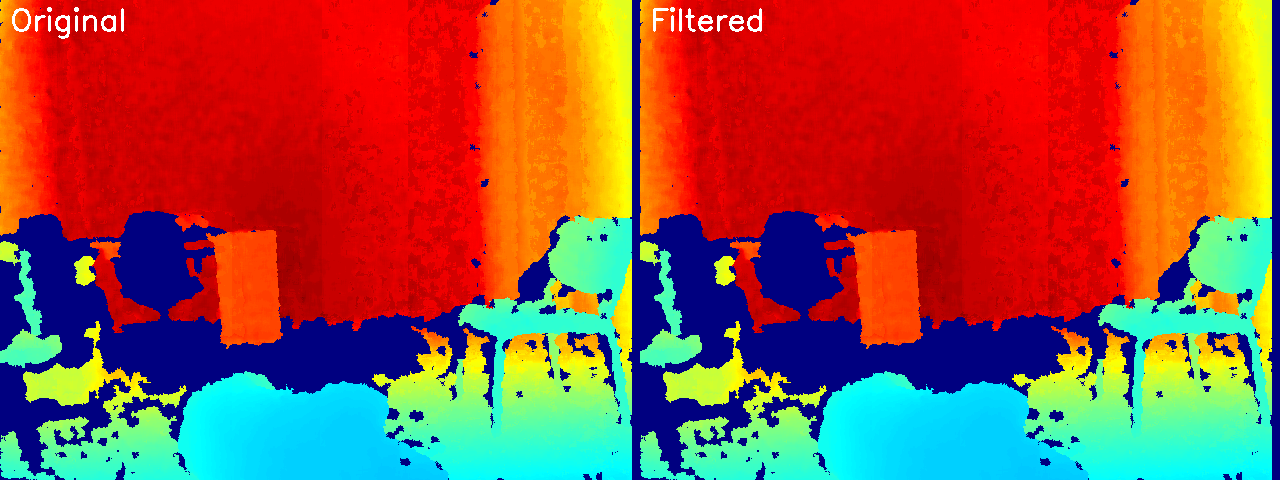

In [8]:
display_sequence(frames, compare_frames=filtered_data_temporal, colormap=cv2.COLORMAP_JET, compare_colormap=cv2.COLORMAP_JET, 
                 labels=["Original", "Filtered"], fps=60)

#### 2D Filtering
To reduce the noise across the frame, we apply a bilateral filter.

The bilateral filter enables us to smooth the image while preserving the edges.

In [9]:
import numpy as np
import cv2

def apply_spatial_bilateral_filter(sequence_tensor, kernel_size=7):
    """
    Applies a spatial bilateral filter frame-by-frame.
    """

    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be odd.")
        
    filtered_tensor = np.empty_like(sequence_tensor)
    
    for i in range(sequence_tensor.shape[0]):
        filtered_tensor[i] = cv2.bilateralFilter(sequence_tensor[i], d=kernel_size, sigmaColor=75, sigmaSpace=75)
        
    return filtered_tensor
filtered_data_bilateral = apply_spatial_bilateral_filter(filtered_data_temporal)

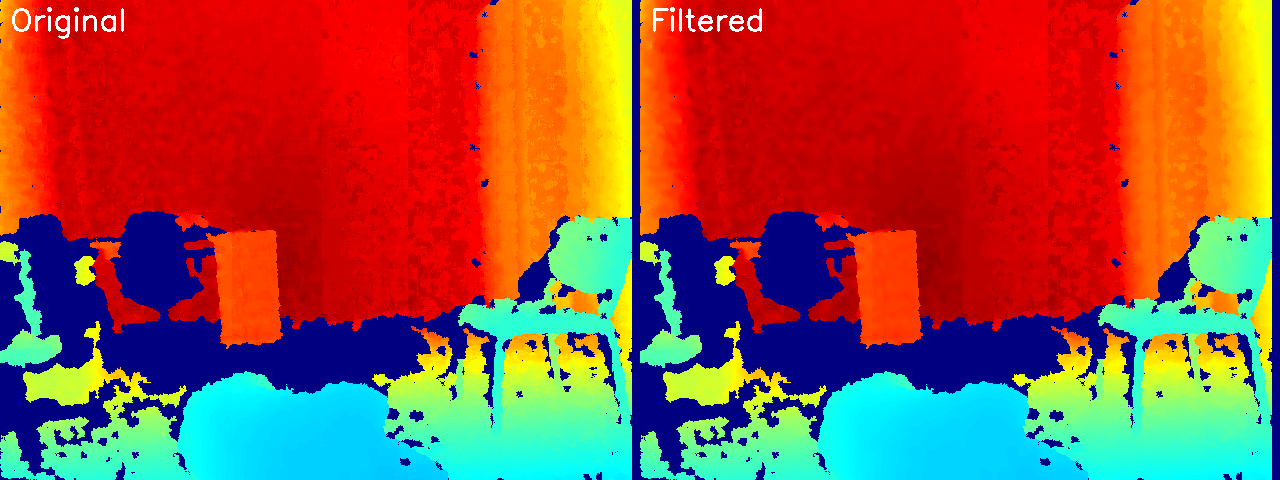

In [10]:
display_sequence(frames, compare_frames=filtered_data_bilateral, colormap=cv2.COLORMAP_JET, compare_colormap=cv2.COLORMAP_JET,
                 labels=["Original", "Filtered"], fps=60)

### 2. Foreground extraction

Traditional background subtraction methods do not work reliably on depth images. In addition, this dataset contains very short sequences in which the subject appears in every frame, making it difficult to isolate the foreground using standard background removal techniques.

A simple but effective algorithm was implemented to extract the foreground, based on a few assumptions:
1. The human subject is the only moving entity in the scene and constitutes the foreground.
2. The background is always farther than the foreground.
3. For each pixel $(x,y)$ there is at least one frame $t$ in the sequence where the pixel captures the static background.
4. The sensor is never moved for the duration of a sequence.

Based on these assumptions, we can calculate the background model $B(x,y)$ by taking the maximum depth value aross the time axis $T$:

$$B(x, y) = \max_{t \in T} D(x, y, t)$$

We can then use this model to isolate the foreground, masking invalid pixels and applying a threshold to account for noise.

In a real-time deployment setting, we can still use this algorithm by providing an initial warm-up time with an empty scene to allow the algorithm to build the background model. Each time the camera is moved, the backgound model should be recalculated.

In [11]:
def extract_foreground_naif(sequence_tensor, tau=60):
    
    background_model = np.max(sequence_tensor, axis=0)

    foreground_mask = (sequence_tensor > 0) & (sequence_tensor < background_model - tau)
    extracted_foreground = np.where(foreground_mask, sequence_tensor, 0)

    return foreground_mask.astype(np.uint8), extracted_foreground

filtered_data = apply_spatial_bilateral_filter(apply_temporal_median_filter(frames))
foreground_masks, foreground = extract_foreground_naif(filtered_data, tau=60)
foreground_masks_unfiltered, foreground_unfiltered = extract_foreground_naif(frames, tau=60)


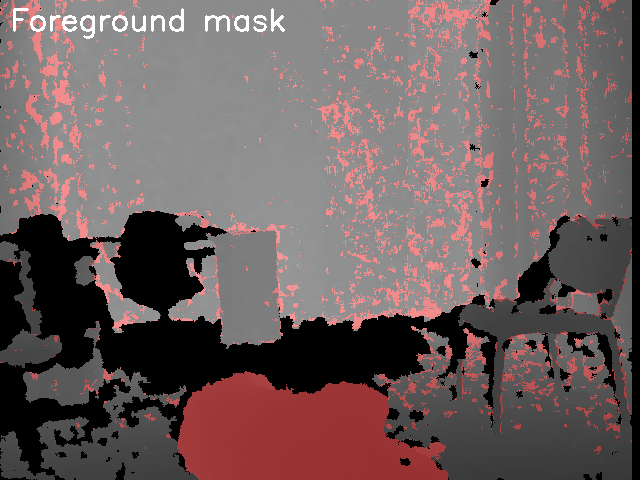

In [12]:
display_sequence(filtered_data, masks=foreground_masks, labels=["Foreground mask"], fps=30)

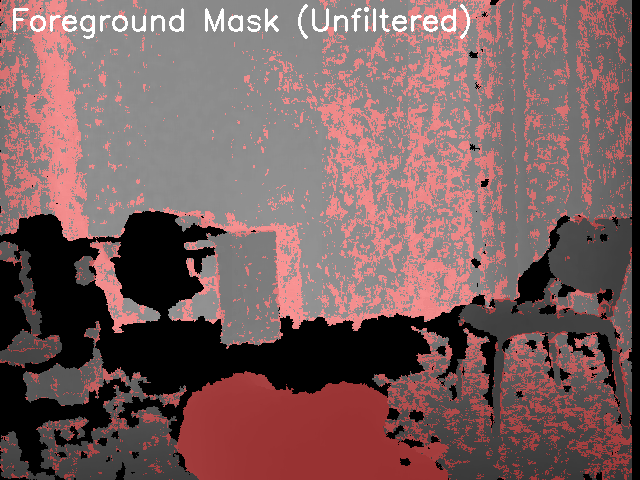

In [13]:
display_sequence(frames, masks=foreground_masks_unfiltered, labels=["Foreground Mask (Unfiltered)"], fps=30)

#### Comment on the filtering approach
The effectiveness of the filtering that was applied to the images is significant, and can be seen from the comparison above: the foreground extraction from the filtered data is more stable and less noisy.

#### Comment on the background modeling approach
We can see that filtering the data only gets us so far when dealing with the Kinect: the result of the foreground extraction is still noisy, and trying to do connected component analysis on this data would not give us the correct result.

To refine our approach, we need to take into consideration the error modeling of the sensor, remembering that both the depth resolution and measurement error increase quadratically with distance. We can introduce an adaptive threshold:

$$\tau(Z) = \tau_{base} + k \cdot \sigma_Z$$

Empirically, the following values were found, that yield good results:
- $\tau_{base} = 15.0 mm$: this value absorbs the constant noise across the image.
- $k = 5$: if the noise were to be perfectly gaussian, a value of 3 would have been sufficient to absorb 99.73% of the noise. The error model does not take into account other non-gaussian artifacts that influence the measurements.

Finally, a background model based on the maximum recorded depth is susceptible to random fluctuations. To make the model more robust to noise we can extract the 95th percentile to filter out the 5% highest values instead of the max.

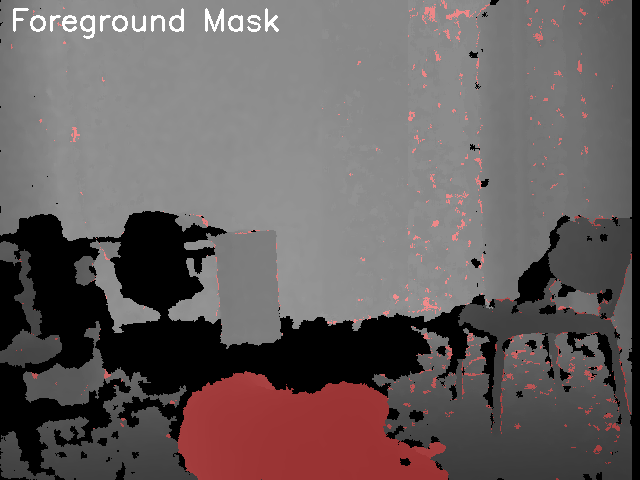

In [14]:
import numpy as np

def extract_foreground_refined(sequence_tensor, tau_base=15.0, k_sigma=5, percentile=95):
    """
    
    Args:
        sequence_tensor (np.ndarray): 3D tensor (T, H, W) of depth frames in millimeters. float32 type.
        tau_base (float): Static threshold (mm) absorbing quantization steps and thermal noise.
        k_sigma (float): Multiplier for the theoretical standard deviation to bound non-Gaussian noise.
        percentile (float): Percentile for background model extraction.
    Returns:
        np.ndarray: Binary mask of the foreground (uint8).
        np.ndarray: Extracted foreground depth data (float32), background set to np.nan.
    """

    background_model = np.percentile(sequence_tensor, percentile, axis=0)
    
    # sigma_Z = (m/fb) * Z^2 * sigma_d'
    sigma_z = 1.425e-6 * (background_model ** 2)
    
    adaptive_tau = tau_base + (k_sigma * sigma_z)
    
    valid_pixels = sequence_tensor > 0
    foreground_condition = sequence_tensor < (background_model - adaptive_tau)
    
    foreground_masks = valid_pixels & foreground_condition
    
    extracted_foreground = np.where(foreground_masks, sequence_tensor, 0.0)

    return foreground_masks.astype(np.uint8), extracted_foreground

foreground_masks, foreground = extract_foreground_refined(filtered_data, tau_base=15.0, k_sigma=5, percentile=95)
foreground_masks_max, foreground_max = extract_foreground_refined(filtered_data, tau_base=15.0, k_sigma=5, percentile=100)
display_sequence(filtered_data, masks=foreground_masks, labels=["Foreground Mask"], fps=60)

In the following cell we can see the noise that gets absorbed by 95th the percentile background model.

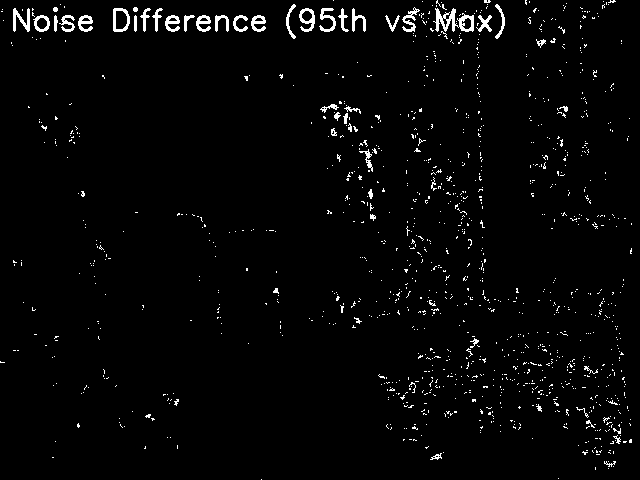

In [15]:
noise_difference = foreground_masks - foreground_masks_max
display_sequence(noise_difference, labels=["Noise Difference (95th vs Max)"], fps=60)

### 3. Binarization

The next step of the pipeline is the binarization of the image.

To do this, first we apply Morphological Operations to clean up the remaining noise and fill any holes in the mask.

1. Opening: erosion followed by dilation, that removes small noisy pixels and thin filaments that may appear around the subject.
2. Closing: dilation followed by erotion, this operation joins fragmented components of the subject and fills small holes within the mask.



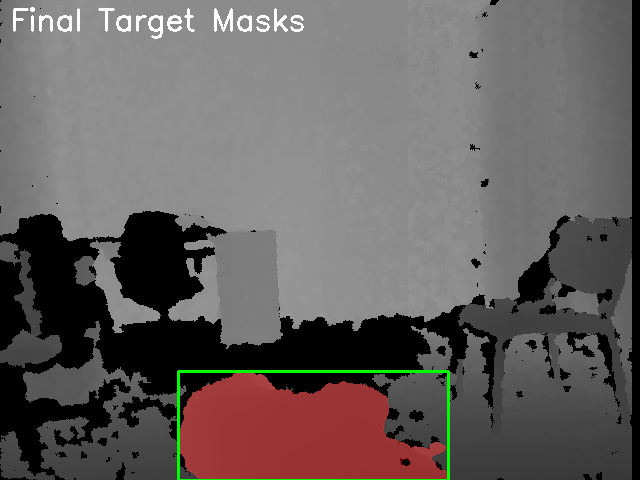

In [16]:
import numpy as np
import cv2

def extract_main_blob(foreground_masks, min_area_px=1500, kernel_size_open=5, kernel_size_close=7):
    """
    Applies morphological operations and extract the largest connected component in the scene.
    """
    T, H, W = foreground_masks.shape
    
    final_masks = np.zeros_like(foreground_masks)
    bboxes = []

    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size_open, kernel_size_open))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size_close, kernel_size_close))
    
    for t in range(T):
        mask = foreground_masks[t]

        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)

        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
        
        bbox = None
        
        if num_labels > 1:
            areas = stats[1:, cv2.CC_STAT_AREA]
            
            # We assume the human is the largest entity
            largest_label = np.argmax(areas) + 1
            largest_area = stats[largest_label, cv2.CC_STAT_AREA]
            
            # simple filter to remove small artifacts
            if largest_area >= min_area_px:
                final_masks[t][labels == largest_label] = 1
                
                x = stats[largest_label, cv2.CC_STAT_LEFT]
                y = stats[largest_label, cv2.CC_STAT_TOP]
                w = stats[largest_label, cv2.CC_STAT_WIDTH]
                h = stats[largest_label, cv2.CC_STAT_HEIGHT]
                
                bbox = (x, y, w, h)
                
        bboxes.append(bbox)
        
    return final_masks, bboxes

target_masks, sequence_bboxes = extract_main_blob(foreground_masks)

display_sequence(filtered_data, masks=target_masks, bboxes=sequence_bboxes, labels=["Final Target Masks"], fps=60)

### Camera Intrinsics

The next steps of the pipeline require going from 2D to 3D domain. Therefore we need the intrinsic parameters of the Kinect.

Normally, we would do camera calibration to estimate the parameters, however, here we are using a pre-acquired dataset that does not come with calibration data.

We can use nominal values of the Kinect v1 found in this paper: https://ieeexplore.ieee.org/document/6130380.
This approach is sub-optimal, but we can see that it provides fairily accurate results.

In [17]:
fx, fy, cx, cy = 585.6, 585.6, 316.0, 247.6
kc1, kc2, kc3, kc4, kc5 = -0.1296, 0.45, -0.0005, -0.002, 0.0
intrinsics_tuple = (fx, fy, cx, cy)
distortion_tuple = (kc1, kc2, kc3, kc4, kc5)

### Floor plane extraction using RANSAC

In [18]:
import pyransac3d as pyrsc

def extract_floor_plane(frame_mm, intrinsics, roi_ratio=0.2, residual_threshold_mm=20.0, max_planes=2):
    """
    Extracts the dominant floor plane from a depth frame using RANSAC.
    Discriminates between floors and beds/tables by selecting the physically lowest plane.
    """
    H, W = frame_mm.shape
    fx, fy, cx, cy = intrinsics

    # 1. ROI extraction and De-projection
    start_y = int(H * roi_ratio)
    u_coords, v_coords = np.meshgrid(np.arange(W), np.arange(start_y, H))
    
    z_flat = frame_mm[start_y:, :].flatten()
    u_flat = u_coords.flatten()
    v_flat = v_coords.flatten()
    
    valid_mask = z_flat > 0
    Z_valid = z_flat[valid_mask]
    U_valid = u_flat[valid_mask].astype(np.float32)
    V_valid = v_flat[valid_mask].astype(np.float32)
    
    if Z_valid.size < 100:
        raise ValueError("Point cloud too sparse for reliable plane fitting.")
        
    X_valid = (U_valid - cx) * Z_valid / fx
    Y_valid = (V_valid - cy) * Z_valid / fy
    
    points = np.column_stack((X_valid, Y_valid, Z_valid))

    plane = pyrsc.Plane()
    found_planes = []
    current_points = points.copy()

    for i in range(max_planes):
        if len(current_points) < 100: 
            break

        eq, inliers = plane.fit(current_points, thresh=residual_threshold_mm, maxIteration=1000)
        A, B, C, D = eq

        # Is the plane horizontal?
        norm_length = np.sqrt(A**2 + B**2 + C**2)
        n_y = B / norm_length
        
        if abs(n_y) > 0.5:
            # Calculating the height of the plane
            # Y = -D/B
            y_height = -D / B
            found_planes.append({
                'eq': eq,
                'y_height': y_height
            })
        
        # removing inliers for the next iteration
        mask = np.ones(len(current_points), dtype=bool)
        mask[inliers] = False
        current_points = current_points[mask]

    if not found_planes:
        raise ValueError("No horizontal plane detected in the ROI.")
    
    found_planes.sort(key=lambda plane: plane['y_height'], reverse=True)
    best_plane = found_planes[0]['eq']

    # Normalize the plane equation
    A, B, C, D = best_plane
    norm = np.sqrt(A**2 + B**2 + C**2)
    A, B, C, D = A/norm, B/norm, C/norm, D/norm
    
    if B > 0:
        A, B, C, D = -A, -B, -C, -D
        
    return A, B, C, D

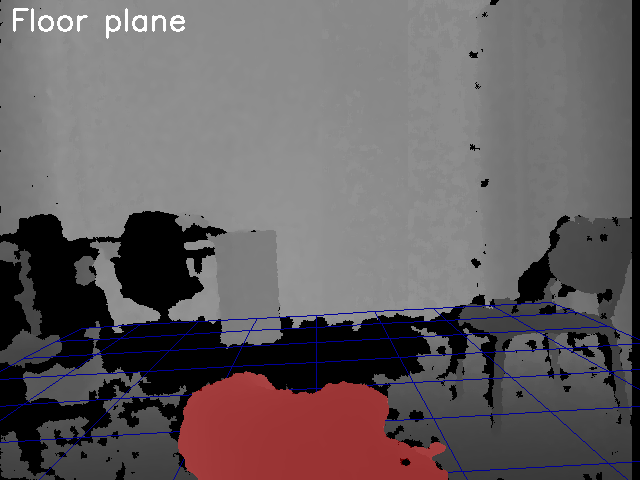

In [19]:
A, B, C, D = extract_floor_plane(filtered_data[0], intrinsics_tuple)
display_sequence(filtered_data, masks=target_masks, labels=["Floor plane"], plane_eq=(A, B, C, D), intrinsics=intrinsics_tuple, fps=30)

In [20]:
def preprocessing_pipeline(sequence_tensor, intrinsics_tuple, config):

    A, B, C, D = extract_floor_plane(sequence_tensor[0], intrinsics_tuple)
    
    filtered = apply_spatial_bilateral_filter(
            apply_temporal_median_filter(sequence_tensor, config['filtering']['window_size']), 
        config['filtering']['kernel_size'])

    foreground_masks, foreground = extract_foreground_refined(filtered, **config['background_subtraction'])

    target_masks, bboxes = extract_main_blob(foreground_masks, **config['blob_extraction'])

    return target_masks, bboxes, filtered, (A, B, C, D)



In [21]:
params = {
    'filtering': {
        'window_size': 3,
        'kernel_size': 7
    },
    'background_subtraction': {
        'tau_base': 15.0,
        'k_sigma': 5,
        'percentile': 95
    },
    'blob_extraction': {
        'min_area_px': 1500,
        'kernel_size_open': 5,
        'kernel_size_close': 7
    }
}

fps = 30


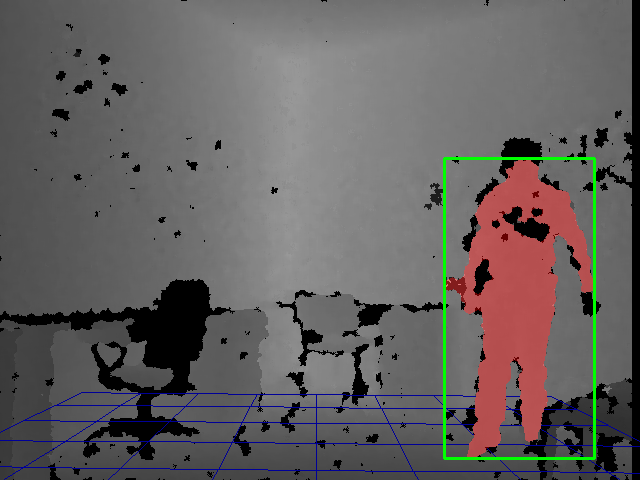

In [23]:
import math
sample = ds.get_adl_sequence(34)

masks, bboxes, filtered, (A, B, C, D) = preprocessing_pipeline( sample['data'], intrinsics_tuple, params)
display_sequence(sample['data'], masks=masks, bboxes=bboxes, plane_eq=(A, B, C, D), intrinsics=intrinsics_tuple, fps=fps)

## 4. Blob Analysis

### Spatial features

We extract the following features from the pointcloud:
- `D_floor`: Distance from the subject's center of mass to the floor plane.
- `H_actual`: Distance from the floor plane to the highest point in the pointcloud.
- `P40`: Percentage of points within 40 cm from the floor.
- `Tilt_Angle`: Angle between the subject's primary axis (first eigenvector) and the floor normal.
- `PCA_Ratio`: Ratio of the first eigenvalue to the second eigenvalue $\frac{\lambda_1}{\lambda_2}$.\
The PCA ratio gives us general information about the pose of the subject by analyzing the variance across the two main axis.\
It tells us how "elongated" the pointcloud is.

In [24]:
import numpy as np

def extract_spatial_features(frame_mm, mask, bbox, intrinsics, floor_plane):

    fx, fy, cx, cy = intrinsics
    A, B, C, D = floor_plane
    floor_normal = np.array([A, B, C])
    
    # We consider only the points within the bounding box
    x, y, w, h = bbox
    roi_z = frame_mm[y:y+h, x:x+w]
    roi_mask = mask[y:y+h, x:x+w]
    
    valid_pixels = (roi_z > 0) & (roi_mask > 0)
    if not np.any(valid_pixels):
        return None
        
    v_coords, u_coords = np.where(valid_pixels)
    v_coords += y
    u_coords += x
    Z = roi_z[valid_pixels]
    
    # 2D to 3D de-projection
    X = (u_coords - cx) * Z / fx
    Y = (v_coords - cy) * Z / fy
    pts_3d = np.column_stack((X, Y, Z))
    N_points = pts_3d.shape[0]
    
    if N_points < 10:
        return None

    # center of mass
    com_3d = np.mean(pts_3d, axis=0)
    # distance from COM to floor
    d_floor = np.abs(np.dot(com_3d, floor_normal) + D)
    
    # Distances from each point to the floor
    dists_to_floor = np.abs(np.dot(pts_3d, floor_normal) + D)
    # max height from the floor
    h_actual = np.max(dists_to_floor)
    # percentage of points within 40 cm from the floor
    p_40 = np.sum(dists_to_floor < 400) / N_points
    
    # PCA
    pts_centered = pts_3d - com_3d
    cov_matrix = np.cov(pts_centered, rowvar=False)
    
    # eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # descending order of eigenvalues
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    v1 = eigenvectors[:, 0] # principal direction
    lambda_1, lambda_2 = eigenvalues[0], eigenvalues[1]
    
    # tilt angle between the principal direction and the floor normal
    cos_theta = np.abs(np.dot(v1, floor_normal))
    tilt_angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

    pca_ratio = lambda_1 / (lambda_2 + 1e-6) # adding epsilon to avoid division by zero
    
    return {
        'com_3d': com_3d,
        'D_floor': d_floor,
        'Tilt_Angle': tilt_angle,
        'PCA_Ratio': pca_ratio,
        'H_actual': h_actual,
        'P40': p_40
    }

### Temporal features

We extract the following features by analyzing the data over time:
- `Velocity_Y`: Vertical velocity of the subject's center of mass. It is calculated as the derivative of `D_floor` over a 5-frame window.
- `HH_Ratio`: Ratio of the current maximum height `H_actual` to the historical maximum recorded height.

In [25]:
from collections import deque

class TemporalFeatureTracker:
    def __init__(self, fps=30, history_seconds=3.0, vy_window_frames=5):
        self.fps = fps
        
        self.com_buffer = deque(maxlen=int(fps * history_seconds))
        self.dfloor_buffer = deque(maxlen=vy_window_frames)
        
        self.h_max_historical = 0.0
        self.dt = 1.0 / fps

    def update_and_extract(self, spatial_features):

        if spatial_features is None:
            return None
            
        com = spatial_features['com_3d']
        d_floor = spatial_features['D_floor']
        h_actual = spatial_features['H_actual']
        
        self.com_buffer.append(com)
        self.dfloor_buffer.append(d_floor)
        
        if h_actual > self.h_max_historical:
            self.h_max_historical = h_actual
        
        # H/H_max ratio
        hh_ratio = h_actual / (self.h_max_historical + 1e-6)
        
        # Velocity estimation of the CoM distance from the floor
        if len(self.dfloor_buffer) < self.dfloor_buffer.maxlen:
            vy = 0.0
        else:
            delta_d = self.dfloor_buffer[-1] - self.dfloor_buffer[0]
            delta_t = self.dt * (len(self.dfloor_buffer) - 1)
            vy = delta_d / delta_t # mm/s
            
        feature_vector = np.array([
            spatial_features['D_floor'],   
            vy,                            
            spatial_features['Tilt_Angle'],
            spatial_features['PCA_Ratio'], 
            spatial_features['H_actual'],  
            hh_ratio,                      
            spatial_features['P40'],       
        ], dtype=np.float32)
        
        return feature_vector

### Features Dashboard
We can plot the dashboard of the extracted features alongside the video to inspect them.

In [26]:
import cv2
import numpy as np

def render_temporal_dashboard(features_history, height, width=400, max_frames=150):
    panel = np.zeros((height, width, 3), dtype=np.uint8)
    
    # 1. Warmup Check
    if not features_history or features_history[-1] is None:
        cv2.putText(panel, "NO TARGET", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)
        return panel

    # Filter out None values generated during tracker warmup
    valid_data = [f for f in features_history if f is not None]
    if len(valid_data) == 0:
        return panel
        
    data = np.array(valid_data) # Shape: (N, 7)
    N = data.shape[0]
    
    # Metadata for the 7 features
    labels = ["D_Floor", "Velocity_Y", "Tilt_Angle", "PCA_Ratio", "H_Actual", "HH_Ratio", "P40"]
    colors = [
        (200, 200, 200), # White/Gray
        (100, 100, 255), # Red
        (255, 150, 50),  # Light Blue
        (100, 255, 100), # Green
        (200, 100, 200), # Purple
        (50, 200, 255),  # Yellow
        (255, 100, 255)  # Magenta
    ]
    
    # 2. Layout Calculation
    num_features = 7
    block_h = height // num_features
    plot_h = block_h - 25 # Reserve top 25px for labels
    
    # Scale X axis dynamically if sequence exceeds expected max_frames
    current_max_frames = max(max_frames, N)
    
    for i in range(num_features):
        y_start = i * block_h
        y_end = y_start + block_h
        
        # Grid Separator
        cv2.line(panel, (0, y_end), (width, y_end), (50, 50, 50), 1)
        
        signal = data[:, i]
        current_val = signal[-1]
        
        # Header text (Label + Real-time Value)
        header_text = f"{labels[i]}: {current_val:.2f}"
        cv2.putText(panel, header_text, (5, y_start + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[i], 1)
        
        if N < 2:
            continue
            
        # 3. Dynamic Auto-Scaling (Y-axis)
        s_min, s_max = np.min(signal), np.max(signal)
        
        # Prevent division by zero for flatlines
        if s_max - s_min < 1e-6:
            s_max += 1.0
            s_min -= 1.0
            
        # Draw Zero-line for velocity or features crossing 0
        if s_min < 0 and s_max > 0:
            zero_y = int(y_end - ((0 - s_min) / (s_max - s_min)) * plot_h)
            cv2.line(panel, (0, zero_y), (width, zero_y), (30, 30, 70), 1)
            
        # 4. Vectorized Point Generation
        x_coords = np.linspace(0, (N / current_max_frames) * width, N)
        y_normalized = (signal - s_min) / (s_max - s_min)
        y_coords = y_end - (y_normalized * plot_h) # Invert Y for OpenCV coordinate system
        
        # Stack coordinates and draw the polyline
        pts = np.column_stack((x_coords, y_coords)).astype(np.int32)
        cv2.polylines(panel, [pts], isClosed=False, color=colors[i], thickness=2)
        
        # Highlight current value point
        cv2.circle(panel, tuple(pts[-1]), 3, (255, 255, 255), -1)

    return panel

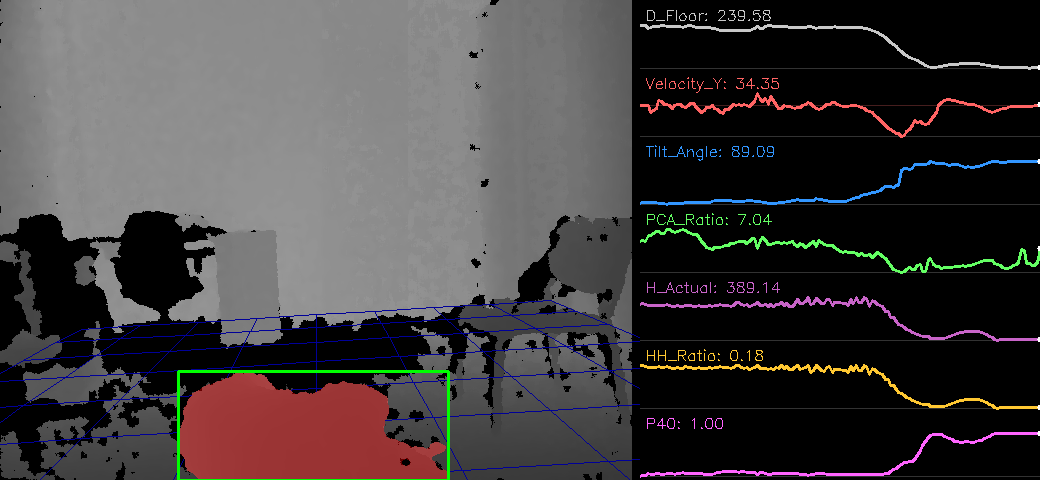

In [27]:
def process_and_display_sequence(frames, mask_sequence, bbox_sequence, intrinsics, floor_eq, fps=30):
    tracker = TemporalFeatureTracker(fps=fps, history_seconds=3.0, vy_window_frames=5)
    
    # 1. Pre-computation Phase
    features_history = []
    
    for t in range(len(frames)):
        frame = frames[t]
        mask = mask_sequence[t]
        bbox = bbox_sequence[t]
        
        if bbox is not None:
            spatial_feats = extract_spatial_features(frame, mask, bbox, intrinsics, floor_eq)
            temporal_vector = tracker.update_and_extract(spatial_feats)
        else:
            temporal_vector = tracker.update_and_extract(None)
            
        features_history.append(temporal_vector)

    # 2. Rendering Phase
    delay = 1.0 / fps
    
    for t in range(len(frames)):
        main_vis = render_frame(
            frames[t], 
            mask=mask_sequence[t], 
            bbox=bbox_sequence[t], 
            plane_eq=floor_eq, 
            intrinsics=intrinsics
        )
        
        current_history = features_history[:t+1]

        telemetry_panel = render_temporal_dashboard(
            current_history, 
            height=main_vis.shape[0], 
            width=400, 
            max_frames=len(frames)
        )
        
        final_canvas = np.hstack((main_vis, telemetry_panel))
        
        # --- Output ---
        ret, encoded_image = cv2.imencode('.png', final_canvas)
        if ret:
            clear_output(wait=True)
            display(Image(data=encoded_image.tobytes()))
            time.sleep(delay)

fps = 30
sample = ds.get_fall_sequence(4)
frames = sample['data']
masks, bboxes, filtered, floor_plane = preprocessing_pipeline(frames, intrinsics_tuple, params)
process_and_display_sequence(filtered, masks, bboxes, intrinsics_tuple, floor_plane, fps=fps)

### Dataset parsing
The whole dataset is parsed and the final csv is built using the functions above. Additionally, the dashboard is rendered for all of the sequences and exported as mp4.

The code used can be found in the final section of the notebook.

## Machine Learning
The last step is to use our extracted features to train and test a machine learning model.

In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv("fall_dataset_features.csv")
df = df.rename(columns={'Label': 'Is_Fall_Sequence'}) 
display(df.head())
display(df.describe())

,Sequence_ID,Frame_Idx,D_Floor,Velocity_Y,Tilt_Angle,PCA_Ratio,H_Actual,HH_Ratio,P40,Is_Fall_Sequence
0,fall-01,0,1010.64070,0.000000,2.666101,7.873872,1812.5067,1.000000,0.052496,1
1,fall-01,1,1013.91290,0.000000,2.608887,8.091739,1770.6274,0.976894,0.054267,1
2,fall-01,2,1014.65740,0.000000,3.238032,8.649171,1774.9637,0.979287,0.057833,1
3,fall-01,3,1015.09015,0.000000,3.774012,9.456709,1815.6478,1.000000,0.067683,1
4,fall-01,4,1016.79100,46.127472,4.124988,10.117341,1809.9312,0.996851,0.071814,1


,Frame_Idx,D_Floor,Velocity_Y,Tilt_Angle,PCA_Ratio,H_Actual,HH_Ratio,P40,Is_Fall_Sequence
count,11606.000000,11606.000000,11606.000000,11606.000000,11606.000000,11606.000000,11606.000000,11606.000000,11606.000000
mean,110.451749,691.729414,-84.348717,31.548046,5.760721,1394.378991,0.668868,0.301036,0.258056
std,80.536962,270.342658,294.169975,32.372069,3.647845,611.530911,0.280090,0.292715,0.437584
min,0.000000,135.068510,-2812.139000,0.087726,1.044980,305.896200,0.146107,0.000000,0.000000
25%,45.000000,476.591200,-165.703185,5.314225,3.073470,807.290570,0.398982,0.121080,0.000000
50%,92.000000,745.220920,-34.291699,12.756374,5.175192,1538.235650,0.749183,0.181036,0.000000
75%,163.000000,919.667230,29.696757,66.388064,7.414601,1855.033850,0.934103,0.349029,1.000000
max,399.000000,1324.187100,4757.964000,89.997246,28.619457,2719.906000,1.000000,1.000000,1.000000


### Importing ground truth

To successfully train a model, we need to import the ground truth of the original dataset.

- We can classify a whole sequence as fall or not fall, based on the name of the sequence
- We can classify the current pose of the model, using the `label` data from the urfall dataset (here called `human_pose`). Possible values:
    - `-1` means person is not lying
    - `1` means person is lying on the ground
    - `0` temporary pose, when the person is falling

We can use two approaches:
- pose classification: this would be tricky since we have very few "falling" (human_pose = 0) frames.
- binary label: we compose a new binary label that triggers an alarm (`1`) if the subject is lying or falling (`human_pose != -1`), and exclusively in fall sequences.

In [29]:
# human_pose :  
# '-1' means person is not lying
# '1' means person is lying on the ground
# '0' is temporary pose, when person "is falling"

columns = ["seq_name", "frame_idx", "human_pose", "HeightWidthRatio", "MajorMinorRatio", "BoundingBoxOccupancy", "MaxStdXZ", "HHmaxRatio", "H", "D", "P40"]
df_groundtruth_falls = pd.read_csv("./dataset/urfall-cam0-falls.csv", names=columns)
df_groundtruth_adl = pd.read_csv("./dataset/urfall-cam0-adls.csv", names=columns)

# concatenating the two datasets
df_groundtruth = pd.concat([df_groundtruth_falls, df_groundtruth_adl], ignore_index=True)
print("Combined Ground Truth:")
display(df_groundtruth.head())

# joining the extracted features with the ground truth labels
# we join on sequence name and frame index
# we only keep human_pose on the ground truth as label, and drop the redundant columns
df_final = pd.merge(df, df_groundtruth[['seq_name', 'frame_idx', 'human_pose']], 
                    left_on=['Sequence_ID', 'Frame_Idx'], 
                    right_on=['seq_name', 'frame_idx'], how='inner')
df_final = df_final.drop(columns=['seq_name', 'frame_idx'])

# final label is 1 if the human pose is falling or lying (0 or 1), and only for fall sequences
df_final["Label"] = np.where((df_final["human_pose"] != -1) & (df_final["Is_Fall_Sequence"] == 1), 1, 0)

print("Final Dataset with Ground Truth:")
display(df_final.head())

print(f"Original extracted dataset samples: {len(df)}")
print(f"Final dataset samples after merging with ground truth: {len(df_final)}")

# exporting the final dataset with ground truth labels
df_final.to_csv("fall_dataset_final.csv", index=False)

# maximum and minumum number of frames per sequence
maximum = df_final.groupby("Sequence_ID").size().max()
minimum = df_final.groupby("Sequence_ID").size().min()
print(f" Longest sequence: {maximum} frames")
print(f" Shortest sequence: {minimum} frames")


Combined Ground Truth:


,seq_name,frame_idx,human_pose,HeightWidthRatio,MajorMinorRatio,BoundingBoxOccupancy,MaxStdXZ,HHmaxRatio,H,D,P40
0,fall-01,1,-1,3.1667,2.9098,0.55367,126.0258,1.0324,1899.5366,1055.9988,0.047310
1,fall-01,2,-1,3.3067,2.9699,0.47876,125.5657,1.1251,2070.1193,1065.9506,0.048175
2,fall-01,3,-1,3.1408,3.0506,0.54374,123.1570,1.0161,1869.6442,1055.4955,0.050180
3,fall-01,4,-1,3.4306,3.1435,0.48859,124.5614,1.1251,2070.1193,1076.1464,0.047877
4,fall-01,5,-1,3.6324,3.3012,0.49744,123.6089,1.1251,2070.1193,1075.5053,0.052543


Final Dataset with Ground Truth:


,Sequence_ID,Frame_Idx,D_Floor,Velocity_Y,Tilt_Angle,PCA_Ratio,H_Actual,HH_Ratio,P40,Is_Fall_Sequence,human_pose,Label
0,fall-01,1,1013.91290,0.000000,2.608887,8.091739,1770.6274,0.976894,0.054267,1,-1,0
1,fall-01,2,1014.65740,0.000000,3.238032,8.649171,1774.9637,0.979287,0.057833,1,-1,0
2,fall-01,3,1015.09015,0.000000,3.774012,9.456709,1815.6478,1.000000,0.067683,1,-1,0
3,fall-01,4,1016.79100,46.127472,4.124988,10.117341,1809.9312,0.996851,0.071814,1,-1,0
4,fall-01,5,1014.63540,5.418571,4.320269,10.538633,1783.5900,0.982344,0.074290,1,-1,0


Original extracted dataset samples: 11606
Final dataset samples after merging with ground truth: 11445
 Longest sequence: 368 frames
 Shortest sequence: 54 frames


### Windowed Dataset Building

The static frame-by frame features that we have extracted so far are unable to capture the dynamics of a falling subject.
To successfully teach our model how to classify fall events, we can aggregate the data with a sliding window approach.

We use a 15 frames sliding window with a stride of 2 frames across each sequence. For each of the seven features, we extract the following statistics across the window: mean, standard deviation, 10th percentile, 90th percentile.

Each windows needs to be labeled. Possible approaches:
- label the window as the majority of the frames in the window,
- label the window as the last frame in the window,
- label the window as a fall only if all its frames are falls.

The approach that yields the best results in the test set is the last one of these.

In [30]:

def create_2d_windowed_dataset(df, feature_cols, target_col, window_size, stride):
    """
    Transforms a continuous time-series DataFrame into a 2D tabular dataset 
    by computing statistical aggregations over sliding windows.
    """
    records = []
    
    # Grouping prevents temporal bleeding between different sequences
    for seq_id, group in df.groupby('Sequence_ID'):
        
        features_array = group[feature_cols].values
        targets_array = group[target_col].values
        n_frames = len(features_array)
        
        if n_frames < window_size:
            continue
            
        # Sliding window
        for start in range(0, n_frames - window_size + 1, stride):
            end = start + window_size
            
            window_x = features_array[start:end]
            # label is the majority of the target values in the window
            # window_y = 1 if np.sum(targets_array[start:end]) > (window_size/2) else 0
            
            # label is the last label in the window
            # window_y = targets_array[end - 1]

            # label true if all labels in the window are true
            window_y = 1 if np.all(targets_array[start:end] == 1) else 0
            
            # Initialize the row dictionary
            row_data = {
                'Sequence_ID': seq_id,
                'Window_End_Frame': group['Frame_Idx'].iloc[end - 1],
                'Label': window_y
            }
            
            # Compute statistical features for the 2D row
            for i, col_name in enumerate(feature_cols):
                col_data = window_x[:, i]
                row_data[f'{col_name}_mean'] = np.mean(col_data)
                row_data[f'{col_name}_std']  = np.std(col_data)
                # row_data[f'{col_name}_min']  = np.min(col_data)
                # row_data[f'{col_name}_max']  = np.max(col_data)
                # row_data[f'{col_name}_median'] = np.median(col_data)
                row_data[f'{col_name}_p10'] = np.percentile(col_data, 10)
                row_data[f'{col_name}_p90'] = np.percentile(col_data, 90)
                
            records.append(row_data)
            
    # Compile the final 2D DataFrame
    return pd.DataFrame(records)

# --- Execution ---
feature_columns = [
    'D_Floor', 'Velocity_Y', 'Tilt_Angle', 'PCA_Ratio', 
    'H_Actual', 'HH_Ratio', 'P40'
]

# Generate the 2D tabular dataset
df_windowed = create_2d_windowed_dataset(
    df_final, 
    feature_cols=feature_columns, 
    target_col='Label', 
    window_size=15, 
    stride=5
)

print(f"Windowed Dataset Shape: {df_windowed.shape}")
display(df_windowed.head())

# export 
df_windowed.to_csv("fall_dataset_windowed.csv", index=False)

Windowed Dataset Shape: (2111, 31)


,Sequence_ID,Window_End_Frame,Label,D_Floor_mean,D_Floor_std,D_Floor_p10,D_Floor_p90,Velocity_Y_mean,Velocity_Y_std,Velocity_Y_p10,...,H_Actual_p10,H_Actual_p90,HH_Ratio_mean,HH_Ratio_std,HH_Ratio_p10,HH_Ratio_p90,P40_mean,P40_std,P40_p10,P40_p90
0,adl-01,21,0,923.134293,16.993900,902.247284,948.488960,109.591617,149.863389,-36.430861,...,1671.11634,1724.48498,0.969569,0.013948,0.956984,0.989018,0.078458,0.010909,0.068393,0.091151
1,adl-01,26,0,936.910891,15.559771,914.432520,952.707116,92.364417,87.299821,-6.633869,...,1671.11634,1769.95436,0.951141,0.039362,0.890163,0.996258,0.075772,0.007632,0.068996,0.087356
2,adl-01,31,0,948.559079,8.822299,937.306342,957.887640,64.350470,119.816004,-30.552340,...,1639.70432,1826.81956,0.923830,0.053701,0.860359,0.996258,0.072582,0.003382,0.068996,0.077470
3,adl-01,36,0,946.466808,9.966731,932.258336,957.887640,-24.343454,85.191792,-107.333994,...,1639.77672,1792.18892,0.890307,0.039669,0.857248,0.936927,0.073815,0.003299,0.069521,0.078340
4,adl-01,41,0,939.314327,12.707915,925.817700,956.039184,-47.753950,80.785341,-112.592946,...,1634.62744,1693.61358,0.877874,0.026615,0.854556,0.885393,0.075183,0.002982,0.072422,0.078964


### Train/Test split

To split our dataset, we need to take two important things into consideration:
- It is crucial to not split the individual sequences to avoid data leaks
- Since the dataset is imbalanced, the split must preserve the class distributions

This is implemented by `StratifiedGroupKFold`.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

df_windowed = pd.read_csv("fall_dataset_windowed.csv")

feature_cols = [col for col in df_windowed.columns if col not in ['Sequence_ID', 'Window_End_Frame', 'Label']]

X = df_windowed[feature_cols]
y = df_windowed['Label']
groups = df_windowed['Sequence_ID']

sgkf_split = StratifiedGroupKFold(n_splits=3)
train_idx, test_idx = next(sgkf_split.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print(f"Training shapes - X: {X_train.shape}, y: {y_train.shape}")
print(f"Testing shapes  - X: {X_test.shape}, y: {y_test.shape}")

test_sequences = groups.iloc[test_idx].values
train_sequences = groups.iloc[train_idx].values

print(f"Train set: {len(np.unique(train_sequences))} sequences ")
print(np.unique(train_sequences))
print(f"Test set: {len(np.unique(test_sequences))} sequences ")
print(np.unique(test_sequences))
print(f"Train Fall ratio: {y_train.mean():.3f}")
print(f"Test Fall ratio:  {y_test.mean():.3f}")

print(f"{len(train_idx) / len(X):.2%} train, {len(test_idx) / len(X):.2%} test")


Training shapes - X: (1411, 28), y: (1411,)
Testing shapes  - X: (700, 28), y: (700,)
Train set: 47 sequences 
['adl-01' 'adl-02' 'adl-03' 'adl-05' 'adl-07' 'adl-08' 'adl-09' 'adl-10'
 'adl-12' 'adl-14' 'adl-16' 'adl-18' 'adl-19' 'adl-21' 'adl-23' 'adl-25'
 'adl-27' 'adl-28' 'adl-29' 'adl-31' 'adl-33' 'adl-35' 'adl-36' 'adl-37'
 'adl-38' 'adl-39' 'adl-40' 'fall-01' 'fall-02' 'fall-05' 'fall-06'
 'fall-08' 'fall-09' 'fall-10' 'fall-12' 'fall-13' 'fall-15' 'fall-16'
 'fall-18' 'fall-20' 'fall-22' 'fall-23' 'fall-24' 'fall-25' 'fall-27'
 'fall-28' 'fall-29']
Test set: 23 sequences 
['adl-04' 'adl-06' 'adl-11' 'adl-13' 'adl-15' 'adl-17' 'adl-20' 'adl-22'
 'adl-24' 'adl-26' 'adl-30' 'adl-32' 'adl-34' 'fall-03' 'fall-04'
 'fall-07' 'fall-11' 'fall-14' 'fall-17' 'fall-19' 'fall-21' 'fall-26'
 'fall-30']
Train Fall ratio: 0.127
Test Fall ratio:  0.127
66.84% train, 33.16% test


### Training and Evaluation

We select a random forest classifier for the aggreagated temporal features. This ensemble model is highly robust and resistant to overfitting.

We use random 5-fold stratified group cross-validation to validate the model **exclusively on train data**.

For the evaluation of the model, the precision metric should be discarded, for two reasons:
- Class Imbalance: the model could favor the majority class (ADL), failing to predict the minority class (Fall).
- Asymmetric Cost of Error: the cost of a false negative (failing to detect an actual fall event) poses a severe health risk. Conversely, a False Positive (triggering an alarm during an ADL) is much less dangerous.

The more relevant metrics to measure the performance of the model are **macro f1-score** and **macro recall**.

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

sgkf_cv = StratifiedGroupKFold(n_splits=5)

print("\n--- CROSS VALIDATION RESULTS ON TRAIN SET ---")
cv_results = cross_validate(
    model, 
    X_train, 
    y_train, 
    groups=groups_train, 
    cv=sgkf_cv, 
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    n_jobs=-1
)

print(f"CV Accuracy:  {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
print(f"CV Precision: {np.mean(cv_results['test_precision_macro']):.4f} (+/- {np.std(cv_results['test_precision_macro']):.4f})")
print(f"CV Recall:    {np.mean(cv_results['test_recall_macro']):.4f} (+/- {np.std(cv_results['test_recall_macro']):.4f})")
print(f"CV F1-Score:  {np.mean(cv_results['test_f1_macro']):.4f} (+/- {np.std(cv_results['test_f1_macro']):.4f})")


--- CROSS VALIDATION RESULTS ON TRAIN SET ---
CV Accuracy:  0.9454 (+/- 0.0171)
CV Precision: 0.9075 (+/- 0.0682)
CV Recall:    0.8526 (+/- 0.0380)
CV F1-Score:  0.8711 (+/- 0.0328)


### Final model evaluation

The final evaluation of the model is done on a *sequence basis* rather than a *frame window basis*.

This is done in order to measure the actual performance of the model in a deployment setting.

The final objective of the model is using the window predictions to classify a sequence as fall (1) or ADL (0).
The alarm (1) triggers if at least **K** of the windows are classified as a fall

The hyperparameter K is fine-tuned using StratifiedGroupKFold on the test set maximizing f1-score

In [33]:
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_predict

print("--- SENSITIVITY ANALYSIS: TRIGGER THRESHOLD (K) ON TRAIN SET ---")

# Generate Out-Of-Fold (OOF) predictions for the training set
# fits the model on each fold and predicts on the held-out fold, ensuring no data leakage
y_pred_train_oof = cross_val_predict(
    model, 
    X_train, 
    y_train, 
    groups=groups_train, 
    cv=sgkf_cv, 
    n_jobs=-1
)

results_train_df = X_train.copy()
results_train_df['True_Window_Label'] = y_train
results_train_df['Predicted_Window_Label'] = y_pred_train_oof
results_train_df['Sequence_ID'] = groups_train.values

k_candidates = range(1, 10)
tuning_results = []

# Evaluate each K threshold at the sequence level
for k in k_candidates:
    sequence_outcomes = []
    for seq_id, group in results_train_df.groupby('Sequence_ID'):
        actual_is_fall = 1 if "fall" in str(seq_id).lower() else 0
        predicted_is_fall = int(group['Predicted_Window_Label'].sum() >= k)
        sequence_outcomes.append({'Actual': actual_is_fall, 'Predicted': predicted_is_fall})
        
    df_eval = pd.DataFrame(sequence_outcomes)
    f1 = f1_score(df_eval['Actual'], df_eval['Predicted'], zero_division=0, average='macro')
    recall = recall_score(df_eval['Actual'], df_eval['Predicted'], zero_division=0)
    precision = precision_score(df_eval['Actual'], df_eval['Predicted'], zero_division=0)
    
    tuning_results.append({'K_Threshold': k, 'F1_Score': f1, 'Recall': recall, 'Precision': precision})

# Display tuning results ordered by F1-Score
tuning_results = sorted(tuning_results, key=lambda x: x['F1_Score'], reverse=True)
df_tuning = pd.DataFrame(tuning_results)
display(df_tuning)

OPTIMAL_K = df_tuning.iloc[0]['K_Threshold']
print(f"\nOptimal K selected based on Training OOF F1-Score: {OPTIMAL_K}")

--- SENSITIVITY ANALYSIS: TRIGGER THRESHOLD (K) ON TRAIN SET ---


,K_Threshold,F1_Score,Recall,Precision
0,3,0.893424,1.00,0.800000
1,1,0.872283,1.00,0.769231
2,2,0.872283,1.00,0.769231
3,4,0.871818,0.95,0.791667
4,5,0.869444,0.85,0.850000
5,6,0.743169,0.55,0.846154
6,7,0.657292,0.40,0.800000
7,8,0.591304,0.25,1.000000
8,9,0.552381,0.20,1.000000



Optimal K selected based on Training OOF F1-Score: 3.0



=== WINDOW-BASED EVALUATION ON TEST SET ===
              precision    recall  f1-score   support

  ADL (Safe)       0.96      0.99      0.97       611
FALL (Alarm)       0.90      0.72      0.80        89

    accuracy                           0.95       700
   macro avg       0.93      0.85      0.89       700
weighted avg       0.95      0.95      0.95       700


=== EVENT-BASED EVALUATION (K = 3.0) ON TEST SET ===
              precision    recall  f1-score   support

  ADL (Safe)       1.00      0.92      0.96        13
FALL (Alarm)       0.91      1.00      0.95        10

    accuracy                           0.96        23
   macro avg       0.95      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



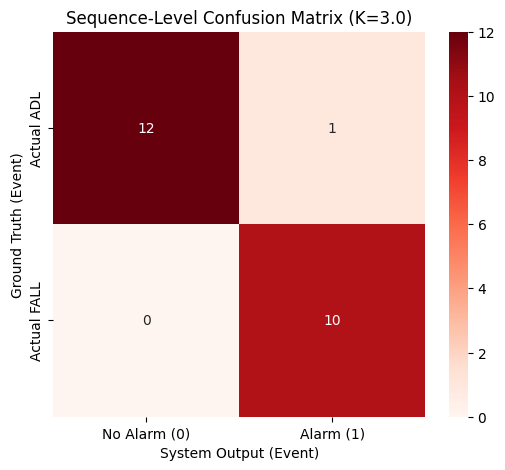


Misclassified Sequences:


,Sequence_ID,Actual_Event,Predicted_Event
10,adl-30,0,1


Sequence: adl-30 | Predicted Fall Windows/Total Windows in Sequence: 5/71


In [34]:
# final evaluation on the test set
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
results_df = X_test.copy()
results_df['True_Window_Label'] = y_test
results_df['Predicted_Window_Label'] = y_pred_test
results_df['Sequence_ID'] = groups.iloc[test_idx].values

print("\n=== WINDOW-BASED EVALUATION ON TEST SET ===")
print(classification_report(results_df['True_Window_Label'], results_df['Predicted_Window_Label'], target_names=['ADL (Safe)', 'FALL (Alarm)']))

print(f"\n=== EVENT-BASED EVALUATION (K = {OPTIMAL_K}) ON TEST SET ===")
final_outcomes = []

for seq_id, group in results_df.groupby('Sequence_ID'):
    actual_is_fall = 1 if "fall" in str(seq_id).lower() else 0
    predicted_is_fall = int(group['Predicted_Window_Label'].sum() >= OPTIMAL_K)
    final_outcomes.append({
        'Sequence_ID': seq_id,
        'Actual_Event': actual_is_fall,
        'Predicted_Event': predicted_is_fall
    })

df_seq_eval = pd.DataFrame(final_outcomes)
y_seq_true = df_seq_eval['Actual_Event']
y_seq_pred = df_seq_eval['Predicted_Event']

print(classification_report(y_seq_true, y_seq_pred, target_names=['ADL (Safe)', 'FALL (Alarm)']))

# 4. Confusion Matrix
cm_seq = confusion_matrix(y_seq_true, y_seq_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_seq, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Alarm (0)', 'Alarm (1)'], 
            yticklabels=['Actual ADL', 'Actual FALL'])
plt.title(f'Sequence-Level Confusion Matrix (K={OPTIMAL_K})')
plt.ylabel('Ground Truth (Event)')
plt.xlabel('System Output (Event)')
plt.show()

# 5. Error Analysis
misclassified = df_seq_eval[df_seq_eval['Actual_Event'] != df_seq_eval['Predicted_Event']]
print("\nMisclassified Sequences:")
display(misclassified)

for seq_id in misclassified['Sequence_ID']:
    seq_windows = results_df[results_df['Sequence_ID'] == seq_id]
    num_predicted_falls = seq_windows['Predicted_Window_Label'].sum()
    print(f"Sequence: {seq_id} | Predicted Fall Windows/Total Windows in Sequence: {num_predicted_falls}/{len(seq_windows)}")

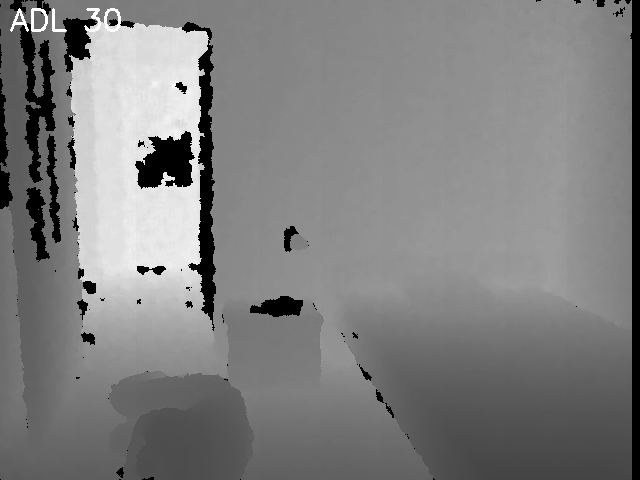

In [35]:
sample = ds.get_adl_sequence(29)
frames = sample['data']
display_sequence(frames, labels=["ADL 30"], fps=30)

## Conclusions

The window-level evaluation yielded a macro F1-score of 0.89 and a macro recall of 0.85. Moving to sequence-level evaluation using temporal aggregation, the model achieved a perfect recall (1.00) with zero missed alarms out of the 10 test fall sequences. However, it generated one false positive on sequence adl-30.  
Sequence adl-30 is part of the trickier edge cases of the dataset, in which the subject lays on the floor in a semi-fetal position and remains motionless. Despite the presence of similar edge-cases in the training set, the model misclassified it.  

While the current pipeline proves the viability of depth-based heuristics, the system has several critical points:

### Dataset Limitations

1. **Limited sample size:** The low number of total sequences restricts the statistical confidence of the metrics and prevents the training of deeper, more robust architectures.
2. **Limited lenght of the sequences:** Sequences are extremely short, often lacking the necessary pre-impact and post-impact context (e.g., the recovery phase) needed to differentiate a fall from a voluntary action.  
3. **Hardware operative range:** The sequences regularly exceed the kinect v1's maximum operating distance of 4.0 meters, recording maximum distances of 6 and 7 meters. This exacerbates the issue of noise, that as stated before scales quadratically with depth.

### Architectural Limitations

1. **State amnesia (Sliding Window):** While the sliding-window approach is able to capture the features of the fall in a small timeframe, it is unable to analyze the whole dynamics of the fall. A better system would need to analyze the fall trajectory throughout the entire sequence.
2. **Morphological feature extraction:** Deriving kinematics from Connected Component Analysis (blobs) and bounding boxes is highly susceptible to partial occlusions and noise.

### Future Expansion

To resolve these structural limitations and improve classification accuracy on edge-cases, future iterations of this system should focus on:

1. **Dataset choice:** The dataset should be larger and have more variance in subjects, poses and locations.
2. **Native Sequence Modeling:** Replacing the static tabular classifiers (Random Forest) with sequence-aware architectures such as Recurrent Neural Networks. This would allow the model to natively learn temporal gradients and trajectory shapes.
3. **Skeletal Pose Estimation:** The original kinect was able to track humans in the scene by extracting the 3D coordinates of the joints and extracting the skeleton, using a machine learning pixel-wise classifier. This approach could be explored for fall detection, as it would provide the position of individual joints even in the presence of noise and occlusions.

## Additional code
The following code block was used to parse the whole dataset and generate videos and the final dataset.

In [ ]:
import cv2
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

def compile_telemetry_and_export_csv(ds, params, intrinsics_tuple, output_video, output_csv, fps=30):
    """
    Compiles the dataset review video with the progressive telemetry dashboard
    and simultaneously exports the extracted features to a CSV file.
    """
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = None
    H_out, W_out = 0, 0
    
    # Pre-allocate list for tabular dataset
    dataset_records = []

    def write_title_card(text, duration_sec=0.5):
        card = np.zeros((H_out, W_out, 3), dtype=np.uint8)
        font_scale = 1.0 if W_out > 600 else 0.7
        thickness = 2
        
        text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)[0]
        text_x = max((W_out - text_size[0]) // 2, 10)
        text_y = (H_out + text_size[1]) // 2
        
        cv2.putText(card, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)
        
        for _ in range(int(fps * duration_sec)):
            video_writer.write(card)

    def process_and_write(sequence_list, label_prefix, label_value):
        nonlocal video_writer, H_out, W_out
        
        for i in tqdm(range(len(sequence_list)), desc=f"Processing {label_prefix}"):
            if label_prefix == "FALL":
                sample = ds.get_fall_sequence(i)
            else:
                sample = ds.get_adl_sequence(i)

            frames = sample['data']
            display_index = i+1
            
            try:
                masks, bboxes, filtered, floor_eq = preprocessing_pipeline(frames, intrinsics_tuple, params)
            except Exception as e:
                print(f"Skipping {label_prefix}_{display_index} due to pipeline error: {e}")
                continue

            # Lazy Initialization
            if video_writer is None:
                dummy_vis = render_frame(filtered[0], plane_eq=floor_eq, intrinsics=intrinsics_tuple)
                dummy_panel = render_temporal_dashboard([None], height=dummy_vis.shape[0], width=400, max_frames=len(filtered))
                
                H_out = dummy_vis.shape[0]
                W_out = dummy_vis.shape[1] + dummy_panel.shape[1]
                
                video_writer = cv2.VideoWriter(output_video, fourcc, fps, (W_out, H_out))
                
            write_title_card(f"{label_prefix} - Seq {display_index}")
            
            tracker = TemporalFeatureTracker(fps=fps, history_seconds=3.0, vy_window_frames=5)
            features_history = []
            
            for t in range(len(filtered)):
                frame = filtered[t]
                mask = masks[t]
                bbox = bboxes[t]

                # --- Extraction ---
                if bbox is not None:
                    spatial_feats = extract_spatial_features(frame, mask, bbox, intrinsics_tuple, floor_eq)
                    temporal_vector = tracker.update_and_extract(spatial_feats)
                else:
                    temporal_vector = tracker.update_and_extract(None)
                    
                features_history.append(temporal_vector)

                # --- Dataset Accumulation ---
                if temporal_vector is not None:
                    record = {
                        'Sequence_ID': f"{label_prefix.lower()}-{display_index:02d}",
                        'Frame_Idx': t,
                        'D_Floor': temporal_vector[0],
                        'Velocity_Y': temporal_vector[1],
                        'Tilt_Angle': temporal_vector[2],
                        'PCA_Ratio': temporal_vector[3],
                        'H_Actual': temporal_vector[4],
                        'HH_Ratio': temporal_vector[5],
                        'P40': temporal_vector[6],
                        'Label': label_value
                    }
                    dataset_records.append(record)

                # --- Frame visualization ---
                main_vis = render_frame(
                    frame, 
                    mask=mask, 
                    bbox=bbox, 
                    plane_eq=floor_eq, 
                    intrinsics=intrinsics_tuple
                )
                
                # --- Dashboard ---
                telemetry_panel = render_temporal_dashboard(
                    features_history[:t+1], 
                    height=main_vis.shape[0],
                    width=400,
                    max_frames=len(filtered)
                )
                
                # --- Stacking  ---
                final_canvas = np.hstack((main_vis, telemetry_panel))
                video_writer.write(final_canvas)

    # --- Execution ---
    print(f"Starting compilation of {output_video} and extraction to {output_csv}...")
    
    # Pass the integer label for CSV target variable
    process_and_write(range(len(ds.get_falls())), "FALL", 1)
    process_and_write(range(len(ds.get_adl())), "ADL", 0)
    
    if video_writer is not None:
        video_writer.release()
        
    # --- CSV Export ---
    df = pd.DataFrame(dataset_records)
    df.to_csv(output_csv, index=False)
    
    print(f"Compilation complete! Total valid frames extracted: {len(df)}")
    return df

# --- Trigger ---
df_dataset = compile_telemetry_and_export_csv(ds, params, intrinsics_tuple, 
                                              output_video="fall_dataset_features_video.mp4", 
                                              output_csv="fall_dataset_features.csv", fps=30)